In [1]:
# ===========================================================
# IMC Prosperity 4 – Round 5 Manual Challenge Optimizer
# Ignith Market: Ashflow Alpha Trading Strategy
# ===========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import product as iterproduct
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_colwidth', 40)

BUDGET = 1_000_000
MAX_BUDGET_FRACTION = 1.0  # 100% total

In [2]:
# ===========================================================
# SECTION 1: FEE & PNL MECHANICS
# ===========================================================

def fee(s: float) -> float:
    """
    Fee for a single product position.
    s: fraction of budget (0 to 1), e.g., 0.10 for 10%
    Returns: fee in XIRECs
    """
    return s**2 * BUDGET


def gross_pnl(s: float, r: float) -> float:
    """
    Gross PnL before fees.
    s: fraction of budget
    r: expected return (decimal, always positive; direction handled by BUY/SELL choice)
    """
    return r * s * BUDGET


def net_pnl(s: float, r: float) -> float:
    """Net PnL = gross PnL - fee"""
    return gross_pnl(s, r) - fee(s)


def breakeven_return(s: float) -> float:
    """
    Minimum return needed to cover the fee at allocation s.
    From: r * s * B = s^2 * B  =>  r = s
    So breakeven return = allocation fraction exactly.
    """
    return s


def optimal_allocation(r: float) -> float:
    """
    Analytical optimal allocation fraction for a single product.
    From d/ds [r*s - s^2] = 0  =>  s* = r/2
    """
    return max(r / 2.0, 0.0)


def max_pnl_single(r: float) -> float:
    """
    Maximum achievable net PnL for a single product (at optimal allocation).
    PnL* = r^2/4 * B
    """
    return (r**2 / 4.0) * BUDGET


# --- Sanity check: verify formulas ---
print("=== FEE STRUCTURE SANITY CHECK ===")
print(f"{'Alloc %':>10} {'Fee (XIRECs)':>15} {'Fee (% Budget)':>15} {'Breakeven Return':>18}")
print("-" * 60)
for pct in [5, 10, 15, 18, 20, 25, 30, 50]:
    s = pct / 100
    f = fee(s)
    print(f"{pct:>9}%  {f:>14,.0f}  {f/BUDGET*100:>13.2f}%  {breakeven_return(s)*100:>17.1f}%")

print("\n=== OPTIMAL ALLOCATION FORMULA ===")
print(f"{'Expected Return':>17} {'Optimal Alloc':>15} {'Max Net PnL':>15}")
print("-" * 50)
for r_pct in [5, 10, 15, 20, 25, 30, 40, 50, 60]:
    r = r_pct / 100
    s_opt = optimal_allocation(r)
    pnl_max = max_pnl_single(r)
    print(f"{r_pct:>15}%  {s_opt*100:>13.1f}%  {pnl_max:>13,.0f}")

=== FEE STRUCTURE SANITY CHECK ===
   Alloc %    Fee (XIRECs)  Fee (% Budget)   Breakeven Return
------------------------------------------------------------
        5%           2,500           0.25%                5.0%
       10%          10,000           1.00%               10.0%
       15%          22,500           2.25%               15.0%
       18%          32,400           3.24%               18.0%
       20%          40,000           4.00%               20.0%
       25%          62,500           6.25%               25.0%
       30%          90,000           9.00%               30.0%
       50%         250,000          25.00%               50.0%

=== OPTIMAL ALLOCATION FORMULA ===
  Expected Return   Optimal Alloc     Max Net PnL
--------------------------------------------------
              5%            2.5%            625
             10%            5.0%          2,500
             15%            7.5%          5,625
             20%           10.0%         10,000
         

In [3]:
# ===========================================================
# SECTION 2: PRODUCT SIGNAL DEFINITIONS
# *** UPDATE THESE WHEN YOU HAVE MORE INFORMATION ***
# ===========================================================

# For each product:
#   'direction'     : 'BUY' or 'SELL' (your chosen side)
#   'r_low'         : pessimistic expected return (decimal) — if trade goes against you
#   'r_base'        : base case expected return (decimal)
#   'r_high'        : optimistic expected return (decimal) — if crowd effect maximises
#   'priced_in'     : 0.0 (fresh news) to 1.0 (fully priced in)
#   'crowd'         : qualitative crowd consensus ('strong buy', 'moderate sell', etc.)
#   'news_summary'  : one-line summary

signals = {
    'Obsidian Cutlery': {
        'direction': 'BUY',        # supply shock interpretation
        'r_low':  0.03,
        'r_base': 0.08,
        'r_high': 0.15,
        'priced_in': 0.00,
        'crowd': 'mixed',
        'news_summary': 'Manufacturing halted; contamination incident; supply disruption',
    },
    'Pyroflex Cells': {
        'direction': 'SELL',
        'r_low':  0.08,
        'r_base': 0.13,
        'r_high': 0.20,
        'priced_in': 0.00,
        'crowd': 'strong sell',
        'news_summary': 'Tax cut removed effective tomorrow; levy effectively doubles',
    },
    'Thermalite Core': {
        'direction': 'BUY',
        'r_low':  0.12,
        'r_base': 0.22,
        'r_high': 0.35,
        'priced_in': 0.00,
        'crowd': 'strong buy',
        'news_summary': 'User forecast: 1.42M → 3.89M next quarter; sustained demand',
    },
    'Lava Cake': {
        'direction': 'SELL',
        'r_low':  0.20,
        'r_base': 0.40,
        'r_high': 0.60,
        'priced_in': 0.00,
        'crowd': 'strong sell',
        'news_summary': 'Actual lava traces confirmed; health review; lawsuits; sales halted',
    },
    'Magma Ink': {
        'direction': 'BUY',        # if anything, residual hype
        'r_low':  0.00,
        'r_base': 0.02,
        'r_high': 0.05,
        'priced_in': 0.90,         # event was yesterday; largely priced in
        'crowd': 'neutral',
        'news_summary': 'Launch was YESTERDAY; already a hot drop; likely priced in',
    },
    'Scoria Paste': {
        'direction': 'BUY',
        'r_low':  0.07,
        'r_base': 0.15,
        'r_high': 0.25,
        'priced_in': 0.10,
        'crowd': 'moderate buy',
        'news_summary': 'Lava D. Ray influencer urging stockpiling; real utility product',
    },
    'Ashes of the Phoenix': {
        'direction': 'SELL',
        'r_low':  0.05,
        'r_base': 0.10,
        'r_high': 0.18,
        'priced_in': 0.00,
        'crowd': 'moderate sell',
        'news_summary': 'Resurfaced sourcing video; public outcry; negative PR',
    },
    'Volcanic Incense': {
        'direction': 'BUY',
        'r_low':  -0.05,           # could reverse if pump already peaked
        'r_base': 0.08,
        'r_high': 0.15,
        'priced_in': 0.40,         # already extended its rally this cycle
        'crowd': 'divided (speculative buy)',
        'news_summary': 'Influencer Whiff Nostralico; already surged; pump-and-dump risk',
    },
    'Sulfur Reactor': {
        'direction': 'BUY',
        'r_low':  0.03,
        'r_base': 0.07,
        'r_high': 0.12,
        'priced_in': 0.30,         # rebalance is "later this cycle", not today
        'crowd': 'moderate buy',
        'news_summary': 'Elemental Index 118 inclusion; rebalance later this cycle',
    },
}

product_names = list(signals.keys())
n_products = len(product_names)

# --- Display the signal table ---
rows = []
for p, s in signals.items():
    rows.append({
        'Product':      p,
        'Direction':    s['direction'],
        'R Low':        f"{s['r_low']*100:.0f}%",
        'R Base':       f"{s['r_base']*100:.0f}%",
        'R High':       f"{s['r_high']*100:.0f}%",
        'Priced In':    f"{s['priced_in']*100:.0f}%",
        'Crowd':        s['crowd'],
    })

df_signals = pd.DataFrame(rows)
print("=== PRODUCT SIGNAL ASSESSMENT ===")
print(df_signals.to_string(index=False))

=== PRODUCT SIGNAL ASSESSMENT ===
             Product Direction R Low R Base R High Priced In                     Crowd
    Obsidian Cutlery       BUY    3%     8%    15%        0%                     mixed
      Pyroflex Cells      SELL    8%    13%    20%        0%               strong sell
     Thermalite Core       BUY   12%    22%    35%        0%                strong buy
           Lava Cake      SELL   20%    40%    60%        0%               strong sell
           Magma Ink       BUY    0%     2%     5%       90%                   neutral
        Scoria Paste       BUY    7%    15%    25%       10%              moderate buy
Ashes of the Phoenix      SELL    5%    10%    18%        0%             moderate sell
    Volcanic Incense       BUY   -5%     8%    15%       40% divided (speculative buy)
      Sulfur Reactor       BUY    3%     7%    12%       30%              moderate buy


In [4]:
# ===========================================================
# SECTION 3: EFFECTIVE RETURN AFTER PRICED-IN ADJUSTMENT
# ===========================================================
# Effective return = raw_return * (1 - priced_in_fraction)
# This discounts signals that are already in the price

def effective_return(r_raw: float, priced_in: float) -> float:
    """Adjust raw expected return for how much is already priced in."""
    return r_raw * (1.0 - priced_in)


# Apply adjustment to all scenarios
scenario_keys = ['r_low', 'r_base', 'r_high']

for p in product_names:
    s = signals[p]
    for sk in scenario_keys:
        key_eff = sk + '_eff'
        s[key_eff] = effective_return(s[sk], s['priced_in'])

# Display effective returns
rows_eff = []
for p, s in signals.items():
    rows_eff.append({
        'Product':          p,
        'Direction':        s['direction'],
        'R Low (raw)':      f"{s['r_low']*100:.0f}%",
        'R Low (eff)':      f"{s['r_low_eff']*100:.0f}%",
        'R Base (raw)':     f"{s['r_base']*100:.0f}%",
        'R Base (eff)':     f"{s['r_base_eff']*100:.0f}%",
        'R High (raw)':     f"{s['r_high']*100:.0f}%",
        'R High (eff)':     f"{s['r_high_eff']*100:.0f}%",
    })

df_eff = pd.DataFrame(rows_eff)
print("=== EFFECTIVE RETURNS AFTER PRICED-IN DISCOUNT ===")
print(df_eff.to_string(index=False))

=== EFFECTIVE RETURNS AFTER PRICED-IN DISCOUNT ===
             Product Direction R Low (raw) R Low (eff) R Base (raw) R Base (eff) R High (raw) R High (eff)
    Obsidian Cutlery       BUY          3%          3%           8%           8%          15%          15%
      Pyroflex Cells      SELL          8%          8%          13%          13%          20%          20%
     Thermalite Core       BUY         12%         12%          22%          22%          35%          35%
           Lava Cake      SELL         20%         20%          40%          40%          60%          60%
           Magma Ink       BUY          0%          0%           2%           0%           5%           0%
        Scoria Paste       BUY          7%          6%          15%          14%          25%          22%
Ashes of the Phoenix      SELL          5%          5%          10%          10%          18%          18%
    Volcanic Incense       BUY         -5%         -3%           8%           5%          15%

In [5]:
# ===========================================================
# SECTION 4: PORTFOLIO OPTIMISER
# Analytical Lagrange solution
# ===========================================================

def optimise_portfolio(returns: np.ndarray,
                       max_total: float = 1.0) -> np.ndarray:
    """
    Analytical portfolio optimisation with budget constraint.

    Math:
    ------
    Unconstrained: s_i* = r_i / 2 for each product.
    If sum(s_i*) <= max_total: done.
    If constraint binds: use Lagrange multipliers.
        L = sum(r_i*s_i - s_i^2) - lambda*(sum(s_i) - max_total)
        FOC: r_i - 2*s_i - lambda = 0  =>  s_i = (r_i - lambda) / 2
        Sum constraint: sum((r_i - lambda)/2) = max_total
        => lambda = (sum(r_i) - 2*max_total) / n_active
    
    Products with s_i < 0 are removed from active set and set to 0.
    We iterate until all active allocations are non-negative.

    Parameters:
    -----------
    returns   : np.array of expected returns (always >= 0 for chosen direction)
    max_total : maximum total fraction of budget (default 1.0)

    Returns:
    --------
    np.array of optimal allocation fractions
    """
    r = np.array(returns, dtype=float)
    n = len(r)

    # Unconstrained optimum
    s_unc = r / 2.0
    if np.sum(s_unc) <= max_total + 1e-9:
        return np.maximum(s_unc, 0.0)

    # Constraint is binding: iterate to find active set
    active = np.ones(n, dtype=bool)

    for _ in range(n + 1):
        r_active = r[active]
        n_active = int(np.sum(active))

        if n_active == 0:
            return np.zeros(n)

        # Lagrange solution for active set
        lam = (np.sum(r_active) - 2.0 * max_total) / n_active
        s_active = (r_active - lam) / 2.0

        if np.all(s_active >= -1e-9):
            result = np.zeros(n)
            result[active] = np.maximum(s_active, 0.0)
            return result

        # Deactivate products with negative allocation
        active_indices = np.where(active)[0]
        neg_mask = s_active < -1e-9
        active[active_indices[neg_mask]] = False

    return np.zeros(n)


def portfolio_stats(allocs: np.ndarray,
                    returns: np.ndarray,
                    product_names: list,
                    directions: list) -> pd.DataFrame:
    """
    Compute detailed stats for a portfolio allocation.
    """
    rows = []
    for i, (p, s, r, d) in enumerate(
            zip(product_names, allocs, returns, directions)):
        inv    = s * BUDGET
        f      = fee(s)
        g_pnl  = gross_pnl(s, r)
        n_pnl  = net_pnl(s, r)
        be_ret = breakeven_return(s)
        rows.append({
            'Product':      p,
            'Direction':    d if s > 1e-4 else 'SKIP',
            'Alloc %':      round(s * 100, 2),
            'Investment':   round(inv, 0),
            'Fee':          round(f, 0),
            'Gross PnL':    round(g_pnl, 0),
            'Net PnL':      round(n_pnl, 0),
            'Breakeven':    f"{be_ret*100:.1f}%",
            'Return Used':  f"{r*100:.1f}%",
        })

    df = pd.DataFrame(rows)

    # Totals row
    totals = {
        'Product':      'TOTAL',
        'Direction':    '',
        'Alloc %':      round(allocs.sum() * 100, 2),
        'Investment':   round(allocs.sum() * BUDGET, 0),
        'Fee':          round(np.sum(allocs**2) * BUDGET, 0),
        'Gross PnL':    round(np.sum(returns * allocs * BUDGET), 0),
        'Net PnL':      round(np.sum((returns * allocs - allocs**2) * BUDGET), 0),
        'Breakeven':    '',
        'Return Used':  '',
    }
    df = pd.concat([df, pd.DataFrame([totals])], ignore_index=True)
    return df

In [6]:
# ===========================================================
# SECTION 5: RUN OPTIMISATION ACROSS ALL SCENARIOS
# ===========================================================

scenarios = {
    'Pessimistic': 'r_low_eff',
    'Base Case':   'r_base_eff',
    'Optimistic':  'r_high_eff',
}

directions = [signals[p]['direction'] for p in product_names]

all_results = {}

for scenario_name, r_key in scenarios.items():
    returns_arr = np.array([signals[p][r_key] for p in product_names])
    allocs      = optimise_portfolio(returns_arr, MAX_BUDGET_FRACTION)
    df_stats    = portfolio_stats(allocs, returns_arr, product_names, directions)

    all_results[scenario_name] = {
        'allocs':  allocs,
        'returns': returns_arr,
        'df':      df_stats,
    }

    total_row   = df_stats.iloc[-1]

    print(f"\n{'='*70}")
    print(f"SCENARIO: {scenario_name.upper()}")
    print(f"{'='*70}")
    print(df_stats.to_string(index=False))
    print(f"\n  Budget used: {total_row['Alloc %']:.2f}%  |  "
          f"Total Fee: {total_row['Fee']:,.0f}  |  "
          f"Expected Net PnL: {total_row['Net PnL']:,.0f} XIRECs")


SCENARIO: PESSIMISTIC
             Product Direction  Alloc %  Investment       Fee  Gross PnL   Net PnL Breakeven Return Used
    Obsidian Cutlery       BUY     1.50   15,000.00    225.00     450.00    225.00      1.5%        3.0%
      Pyroflex Cells      SELL     4.00   40,000.00  1,600.00   3,200.00  1,600.00      4.0%        8.0%
     Thermalite Core       BUY     6.00   60,000.00  3,600.00   7,200.00  3,600.00      6.0%       12.0%
           Lava Cake      SELL    10.00  100,000.00 10,000.00  20,000.00 10,000.00     10.0%       20.0%
           Magma Ink      SKIP     0.00        0.00      0.00       0.00      0.00      0.0%        0.0%
        Scoria Paste       BUY     3.15   31,500.00    992.00   1,985.00    992.00      3.2%        6.3%
Ashes of the Phoenix      SELL     2.50   25,000.00    625.00   1,250.00    625.00      2.5%        5.0%
    Volcanic Incense      SKIP     0.00        0.00      0.00      -0.00     -0.00      0.0%       -3.0%
      Sulfur Reactor       BUY  

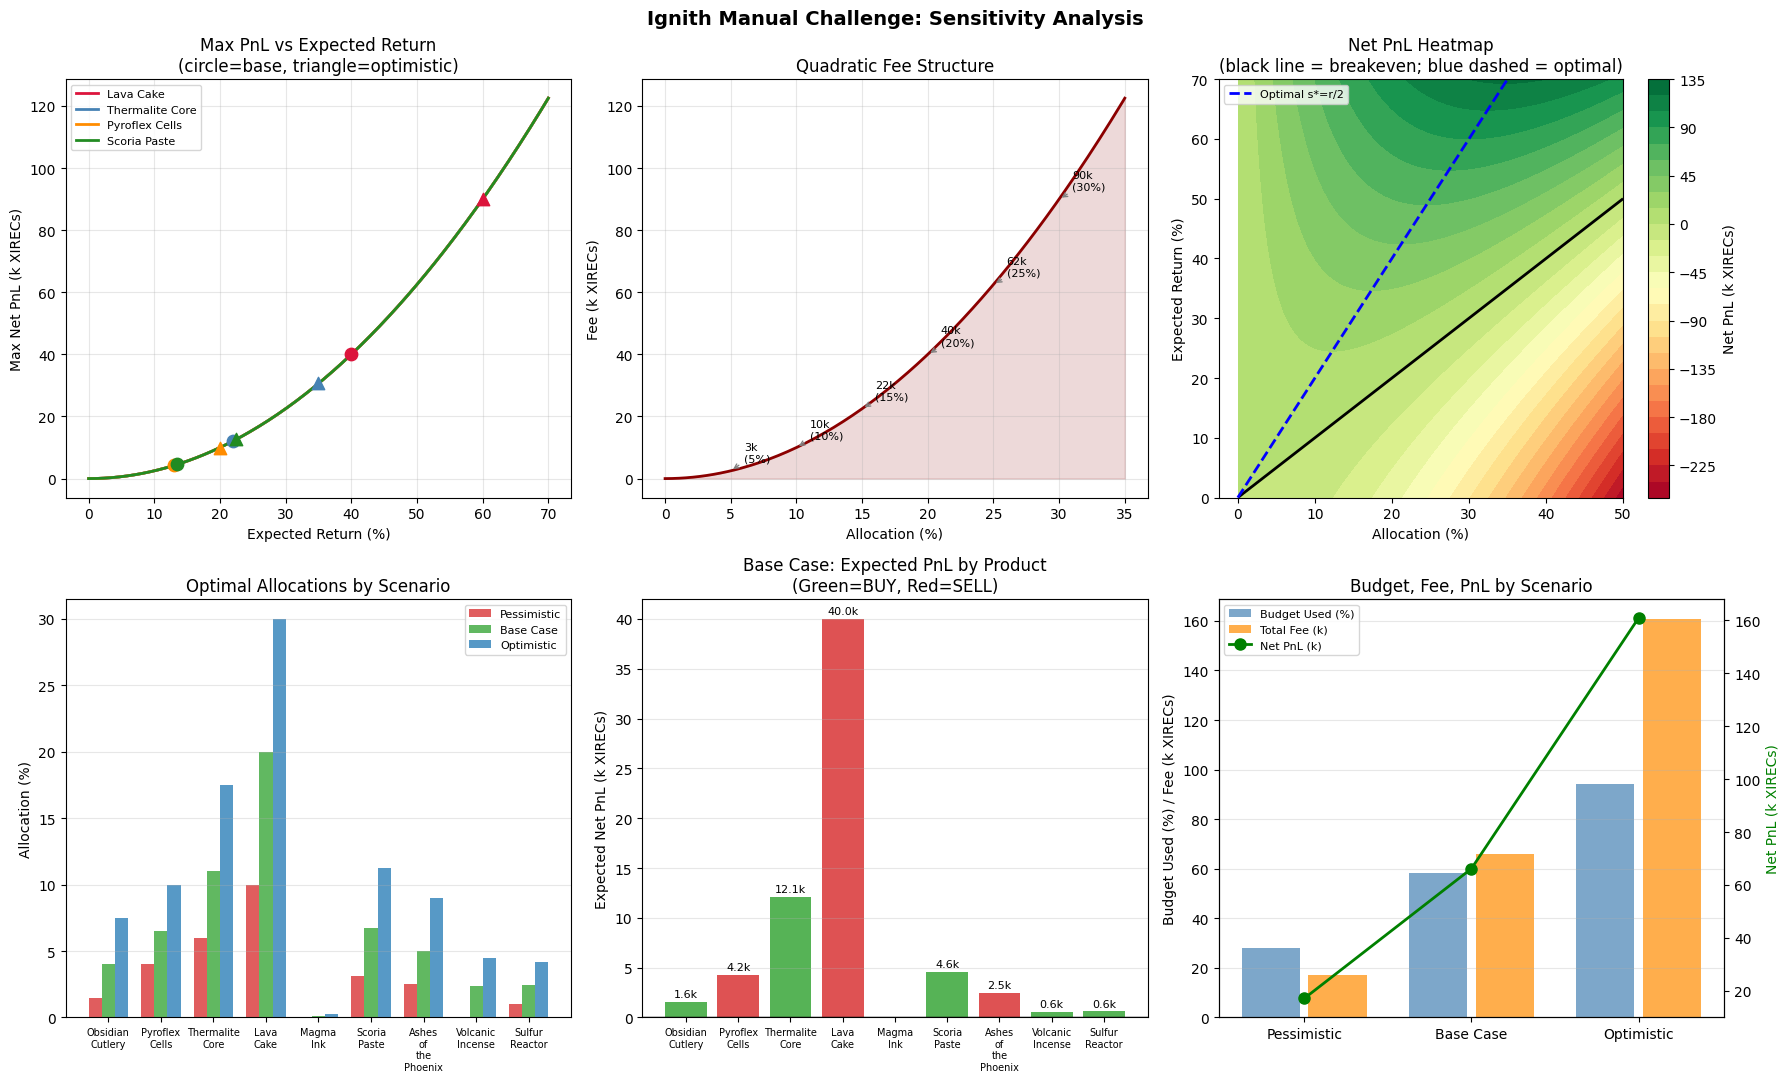

In [7]:
# ===========================================================
# SECTION 6: SENSITIVITY ANALYSIS
# ===========================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Ignith Manual Challenge: Sensitivity Analysis', fontsize=14, fontweight='bold')

# ----- Plot 1: PnL vs return for key products -----
ax = axes[0, 0]
return_range = np.linspace(0.0, 0.70, 300)
key_products = ['Lava Cake', 'Thermalite Core', 'Pyroflex Cells', 'Scoria Paste']
colors_kp    = ['crimson', 'steelblue', 'darkorange', 'forestgreen']

for kp, col in zip(key_products, colors_kp):
    pnls = [max_pnl_single(r) / 1000 for r in return_range]
    ax.plot(return_range * 100, pnls, color=col, label=kp, linewidth=2)
    # mark base and high estimates
    for scenario_key, marker in [('r_base_eff', 'o'), ('r_high_eff', '^')]:
        r_pt = signals[kp][scenario_key]
        if r_pt > 0:
            ax.scatter([r_pt * 100], [max_pnl_single(r_pt) / 1000],
                       color=col, marker=marker, s=80, zorder=5)

ax.set_xlabel('Expected Return (%)')
ax.set_ylabel('Max Net PnL (k XIRECs)')
ax.set_title('Max PnL vs Expected Return\n(circle=base, triangle=optimistic)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ----- Plot 2: Fee vs allocation percentage -----
ax = axes[0, 1]
alloc_pct_range = np.linspace(0, 35, 200)
fees_range = [(a / 100)**2 * BUDGET / 1000 for a in alloc_pct_range]
ax.plot(alloc_pct_range, fees_range, color='darkred', linewidth=2)
ax.fill_between(alloc_pct_range, fees_range, alpha=0.15, color='darkred')

for alloc in [5, 10, 15, 20, 25, 30]:
    f_val = (alloc / 100)**2 * BUDGET / 1000
    ax.annotate(f'{f_val:.0f}k\n({alloc}%)',
                xy=(alloc, f_val),
                xytext=(alloc + 1, f_val + 3),
                fontsize=8,
                arrowprops=dict(arrowstyle='->', color='gray', lw=1))

ax.set_xlabel('Allocation (%)')
ax.set_ylabel('Fee (k XIRECs)')
ax.set_title('Quadratic Fee Structure')
ax.grid(True, alpha=0.3)

# ----- Plot 3: Net PnL contour (allocation vs return) -----
ax = axes[0, 2]
alloc_range_2d = np.linspace(0.001, 0.50, 200)
return_range_2d = np.linspace(0.0, 0.70, 200)
S, R = np.meshgrid(alloc_range_2d, return_range_2d)
Z = (R * S - S**2) * BUDGET / 1000  # net PnL in k

cp = ax.contourf(S * 100, R * 100, Z, levels=30, cmap='RdYlGn')
ax.contour(S * 100, R * 100, Z, levels=[0], colors='black', linewidths=2)
plt.colorbar(cp, ax=ax, label='Net PnL (k XIRECs)')

# Mark optimal line: s* = r/2
r_line = np.linspace(0, 0.70, 200)
ax.plot(r_line / 2 * 100, r_line * 100, 'b--', linewidth=2, label='Optimal s*=r/2')
ax.set_xlabel('Allocation (%)')
ax.set_ylabel('Expected Return (%)')
ax.set_title('Net PnL Heatmap\n(black line = breakeven; blue dashed = optimal)')
ax.legend(fontsize=8)

# ----- Plot 4: Allocation bar chart across scenarios -----
ax = axes[1, 0]
x = np.arange(n_products)
width = 0.25
scenario_colors = ['#d62728', '#2ca02c', '#1f77b4']

for idx, (sname, sdata) in enumerate(all_results.items()):
    allocs_pct = sdata['allocs'] * 100
    bar_colors = []
    for i, p in enumerate(product_names):
        base_col = '#2ca02c' if signals[p]['direction'] == 'BUY' else '#d62728'
        bar_colors.append(base_col)
    ax.bar(x + idx * width, allocs_pct, width, alpha=0.75,
           label=sname, color=scenario_colors[idx])

ax.set_xticks(x + width)
ax.set_xticklabels([p.replace(' ', '\n') for p in product_names], fontsize=7)
ax.set_ylabel('Allocation (%)')
ax.set_title('Optimal Allocations by Scenario')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# ----- Plot 5: Expected PnL by product (base case) -----
ax = axes[1, 1]
base_allocs  = all_results['Base Case']['allocs']
base_returns = all_results['Base Case']['returns']
net_pnls_base = [(r * s - s**2) * BUDGET / 1000
                 for s, r in zip(base_allocs, base_returns)]

bar_colors = ['#2ca02c' if signals[p]['direction'] == 'BUY' else '#d62728'
              for p in product_names]

bars = ax.bar(range(n_products), net_pnls_base, color=bar_colors, alpha=0.8)
ax.set_xticks(range(n_products))
ax.set_xticklabels([p.replace(' ', '\n') for p in product_names], fontsize=7)
ax.set_ylabel('Expected Net PnL (k XIRECs)')
ax.set_title('Base Case: Expected PnL by Product\n(Green=BUY, Red=SELL)')
ax.axhline(y=0, color='black', linewidth=1)
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, net_pnls_base):
    if abs(val) > 0.5:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f'{val:.1f}k', ha='center', va='bottom', fontsize=8)

# ----- Plot 6: Budget utilisation and fee comparison -----
ax = axes[1, 2]
scenario_names = list(all_results.keys())
budgets_used = [all_results[s]['allocs'].sum() * 100 for s in scenario_names]
total_fees   = [np.sum(all_results[s]['allocs']**2) * BUDGET / 1000
                for s in scenario_names]
net_pnls_tot = [all_results[s]['df'].iloc[-1]['Net PnL'] / 1000
                for s in scenario_names]

x3 = np.arange(3)
ax2 = ax.twinx()
ax.bar(x3 - 0.2, budgets_used, 0.35, label='Budget Used (%)',
       color='steelblue', alpha=0.7)
ax.bar(x3 + 0.2, total_fees,  0.35, label='Total Fee (k)',
       color='darkorange', alpha=0.7)
ax2.plot(x3, net_pnls_tot, 'go-', linewidth=2, markersize=8, label='Net PnL (k)')

ax.set_xticks(x3)
ax.set_xticklabels(scenario_names)
ax.set_ylabel('Budget Used (%) / Fee (k XIRECs)')
ax2.set_ylabel('Net PnL (k XIRECs)', color='green')
ax.set_title('Budget, Fee, PnL by Scenario')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ignith_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ===========================================================
# SECTION 7: GAME THEORY / CROWD EFFECT ANALYSIS
# ===========================================================
# Model: actual_return = anchor + crowd_weight * half_range
# crowd_weight ∈ [-1, +1] depending on aggregate submissions
# If most participants go in direction d with fraction f:
#   crowd_weight ≈ tanh(k * f)  (saturates at ±1 for extreme allocations)
# We model this simply: for products with strong consensus,
# use return_high; for mixed consensus, use return_base.

crowd_strength_map = {
    'strong buy':              1.0,
    'strong sell':             1.0,
    'moderate buy':            0.6,
    'moderate sell':           0.6,
    'mixed':                   0.0,
    'neutral':                 0.0,
    'divided (speculative buy)': 0.2,
}

def crowd_adjusted_return(p: str) -> float:
    """
    Blend base and high (or low) return based on crowd strength.
    Strong consensus pushes return toward high/optimistic value.
    Mixed consensus stays at base.
    """
    s = signals[p]
    crowd_w = crowd_strength_map.get(s['crowd'], 0.0)
    r_eff_base = s['r_base_eff']
    r_eff_high = s['r_high_eff']
    # crowd pushes toward high estimate for products with consensus
    return r_eff_base + crowd_w * (r_eff_high - r_eff_base)


crowd_returns = np.array([crowd_adjusted_return(p) for p in product_names])
allocs_crowd  = optimise_portfolio(crowd_returns, MAX_BUDGET_FRACTION)
df_crowd      = portfolio_stats(allocs_crowd, crowd_returns, product_names, directions)

total_crowd   = df_crowd.iloc[-1]

print("=== CROWD-ADJUSTED OPTIMAL PORTFOLIO ===")
print("(Uses high return for strong-consensus products, base for mixed)")
print()
print(df_crowd.to_string(index=False))
print(f"\n  Budget used: {total_crowd['Alloc %']:.2f}%  |  "
      f"Fee: {total_crowd['Fee']:,.0f}  |  "
      f"Net PnL: {total_crowd['Net PnL']:,.0f} XIRECs")

=== CROWD-ADJUSTED OPTIMAL PORTFOLIO ===
(Uses high return for strong-consensus products, base for mixed)

             Product Direction  Alloc %  Investment        Fee  Gross PnL    Net PnL Breakeven Return Used
    Obsidian Cutlery       BUY     4.00   40,000.00   1,600.00   3,200.00   1,600.00      4.0%        8.0%
      Pyroflex Cells      SELL    10.00  100,000.00  10,000.00  20,000.00  10,000.00     10.0%       20.0%
     Thermalite Core       BUY    17.50  175,000.00  30,625.00  61,250.00  30,625.00     17.5%       35.0%
           Lava Cake      SELL    30.00  300,000.00  90,000.00 180,000.00  90,000.00     30.0%       60.0%
           Magma Ink       BUY     0.10    1,000.00       1.00       2.00       1.00      0.1%        0.2%
        Scoria Paste       BUY     9.45   94,500.00   8,930.00  17,860.00   8,930.00      9.4%       18.9%
Ashes of the Phoenix      SELL     7.40   74,000.00   5,476.00  10,952.00   5,476.00      7.4%       14.8%
    Volcanic Incense       BUY     2.

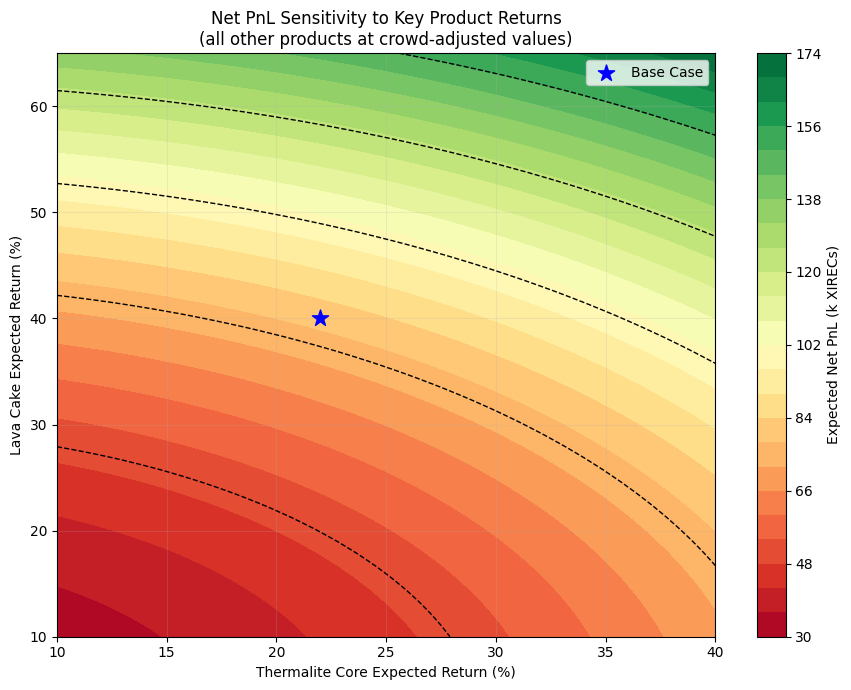

Base case total net PnL: 81.0k XIRECs


In [9]:
# ===========================================================
# SECTION 8: FULL PARAMETER SCAN
# How sensitive is net PnL to our return assumptions?
# ===========================================================

# For the two highest-impact products (Lava Cake, Thermalite),
# do a 2D scan of net PnL across return combinations.

r_lava_range      = np.linspace(0.10, 0.65, 50)
r_thermalite_range = np.linspace(0.10, 0.40, 50)

# Fix all other products at their crowd-adjusted returns
base_other_pnl = 0.0
for i, p in enumerate(product_names):
    if p not in ('Lava Cake', 'Thermalite Core'):
        r = crowd_returns[i]
        s = optimal_allocation(r)
        base_other_pnl += net_pnl(s, r)

pnl_grid = np.zeros((len(r_lava_range), len(r_thermalite_range)))

for i, r_lava in enumerate(r_lava_range):
    for j, r_therm in enumerate(r_thermalite_range):
        s_lava  = optimal_allocation(r_lava)
        s_therm = optimal_allocation(r_therm)
        pnl_lava  = net_pnl(s_lava, r_lava)
        pnl_therm = net_pnl(s_therm, r_therm)
        pnl_grid[i, j] = (pnl_lava + pnl_therm + base_other_pnl) / 1000

fig, ax = plt.subplots(figsize=(9, 7))
cp = ax.contourf(r_thermalite_range * 100, r_lava_range * 100,
                 pnl_grid, levels=25, cmap='RdYlGn')
plt.colorbar(cp, ax=ax, label='Expected Net PnL (k XIRECs)')
ax.contour(r_thermalite_range * 100, r_lava_range * 100,
           pnl_grid, levels=[50, 75, 100, 125, 150],
           colors='black', linewidths=1, linestyles='--')

# Mark our base case
bc_lava  = signals['Lava Cake']['r_base_eff']
bc_therm = signals['Thermalite Core']['r_base_eff']
ax.scatter([bc_therm * 100], [bc_lava * 100],
           color='blue', s=150, zorder=6, label='Base Case', marker='*')

ax.set_xlabel('Thermalite Core Expected Return (%)')
ax.set_ylabel('Lava Cake Expected Return (%)')
ax.set_title('Net PnL Sensitivity to Key Product Returns\n(all other products at crowd-adjusted values)')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('ignith_2d_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Base case total net PnL: {pnl_grid[np.argmin(np.abs(r_lava_range - bc_lava)), np.argmin(np.abs(r_thermalite_range - bc_therm))]:.1f}k XIRECs")

In [10]:
# ===========================================================
# SECTION 9: FINAL RECOMMENDATION + SUBMISSION FORMATTER
# ===========================================================
# Uses crowd-adjusted allocations as the primary recommendation.
# Products with < 0.5% allocation are skipped.

print("=" * 70)
print("FINAL ALLOCATION RECOMMENDATION")
print("=" * 70)
print()

submission_rows = []

for i, p in enumerate(product_names):
    alloc_pct = allocs_crowd[i] * 100
    r         = crowd_returns[i]
    direction = directions[i] if alloc_pct > 0.5 else 'SKIP'
    f         = fee(allocs_crowd[i])
    n_pnl_val = net_pnl(allocs_crowd[i], r)

    submission_rows.append({
        'Product':       p,
        'Direction':     direction,
        'Alloc %':       round(alloc_pct, 1),
        'Expected Ret':  f"{r*100:.1f}%",
        'Breakeven Ret': f"{allocs_crowd[i]*100:.1f}%",
        'Fee (XIRECs)':  int(f),
        'Net PnL Est':   int(n_pnl_val),
        'Crowd':         signals[p]['crowd'],
    })

df_submission = pd.DataFrame(submission_rows)
total_alloc   = df_submission[df_submission['Direction'] != 'SKIP']['Alloc %'].sum()
total_fee_val = sum(r['Fee (XIRECs)'] for _, r in df_submission.iterrows()
                    if r['Direction'] != 'SKIP')
total_pnl_val = sum(r['Net PnL Est'] for _, r in df_submission.iterrows()
                    if r['Direction'] != 'SKIP')

print(df_submission.to_string(index=False))
print()
print(f"  Total Budget Used : {total_alloc:.1f}%  (of 100% max)")
print(f"  Total Fees        : {total_fee_val:,.0f} XIRECs")
print(f"  Expected Net PnL  : {total_pnl_val:,.0f} XIRECs")
print(f"  Unused Budget     : {100 - total_alloc:.1f}%  (expires worthless)")
print()
print("NOTE: Adjust return estimates in Section 2 and re-run if you obtain")
print("      return ranges/anchors from the platform, or additional clues.")
print()

# --- Format for submission entry ---
print("=" * 70)
print("COPY-PASTE FOR SUBMISSION FORM")
print("=" * 70)
for row in submission_rows:
    if row['Direction'] != 'SKIP':
        print(f"  {row['Product']:<30}  {row['Direction']:<5}  {row['Alloc %']:>5.1f}%")

FINAL ALLOCATION RECOMMENDATION

             Product Direction  Alloc % Expected Ret Breakeven Ret  Fee (XIRECs)  Net PnL Est                     Crowd
    Obsidian Cutlery       BUY     4.00         8.0%          4.0%          1600         1600                     mixed
      Pyroflex Cells      SELL    10.00        20.0%         10.0%         10000        10000               strong sell
     Thermalite Core       BUY    17.50        35.0%         17.5%         30624        30624                strong buy
           Lava Cake      SELL    30.00        60.0%         30.0%         90000        90000               strong sell
           Magma Ink      SKIP     0.10         0.2%          0.1%             0            0                   neutral
        Scoria Paste       BUY     9.40        18.9%          9.4%          8930         8930              moderate buy
Ashes of the Phoenix      SELL     7.40        14.8%          7.4%          5475         5475             moderate sell
    Vol